### PROBLEM STATEMENT

The rapid growth of the smartphone market has created a need for accurate price prediction systems that can help manufacturers, retailers, and customers estimate the price of a mobile phone based on its features. The price of a smartphone depends on several factors such as RAM, battery capacity, internal memory, processor speed, camera quality, screen size, and connectivity options.

### PROJECT OBJECTIVES

1. To collect and analyze mobile phone specification data such as RAM, battery power, processor speed, camera quality, and internal memory.
2. To preprocess and clean the dataset for accurate prediction.
3. To identify the important features that affect the price of a cell phone.
4. To develop a Machine Learning model for predicting the price range of mobile phones.
5. To apply different Machine Learning algorithms such as Decision Tree, Random Forest, and Support Vector Machine for prediction.
6. To compare the performance of different algorithms using evaluation metrics like accuracy, precision, and recall.
7. To build an efficient and reliable system that can predict mobile phone prices based on user input specifications.
8. To help customers and mobile retailers make better pricing and purchasing decisions.

### DATASET DESCREPTION

The dataset used in the Cell Phone Price Prediction project contains various technical specifications and features of mobile phones. Each record in the dataset represents a single mobile phone with its corresponding specifications and price range category.

## 1) IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn import metrics
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

## 2) LOAD DATASET

In [2]:
data = pd.read_csv("cellphone_price.csv")

#### INSIGHT 
The Dataset contains cellphone related imformation such as battery power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range

## 3) DATA UNDERSTANDING

In [3]:
data.shape

(2000, 21)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [5]:
data.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [6]:
data.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [7]:
data.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [8]:
data.nunique()

battery_power    1094
blue                2
clock_speed        26
dual_sim            2
fc                 20
four_g              2
int_memory         63
m_dep              10
mobile_wt         121
n_cores             8
pc                 21
px_height        1137
px_width         1109
ram              1562
sc_h               15
sc_w               19
talk_time          19
three_g             2
touch_screen        2
wifi                2
price_range         4
dtype: int64

### 4)DATA CLEANING

In [9]:
data.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [10]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
battery_power,2000.0,1238.51850,439.418206,501.0,851.75,1226.0,1615.25,1998.0
blue,2000.0,0.49500,0.500100,0.0,0.00,0.0,1.00,1.0
clock_speed,2000.0,1.52225,0.816004,0.5,0.70,1.5,2.20,3.0
dual_sim,2000.0,0.50950,0.500035,0.0,0.00,1.0,1.00,1.0
fc,2000.0,4.30950,4.341444,0.0,1.00,3.0,7.00,19.0
four_g,2000.0,0.52150,0.499662,0.0,0.00,1.0,1.00,1.0
int_memory,2000.0,32.04650,18.145715,2.0,16.00,32.0,48.00,64.0
m_dep,2000.0,0.50175,0.288416,0.1,0.20,0.5,0.80,1.0
mobile_wt,2000.0,140.24900,35.399655,80.0,109.00,141.0,170.00,200.0
n_cores,2000.0,4.52050,2.287837,1.0,3.00,4.0,7.00,8.0


#### minimum value of px_height and sc_w (screen width) is zero,0 is NOT realistic
#### So here:
#### 0 = invalid / missing-like value → replace it

##### count of px_height and sc_w

In [11]:
print(len(data[data.px_height ==0]))
print(len(data[data.sc_w == 0]))

2
180


In [12]:
# “Around 10% of values in the sc_w column were zero, which is not realistic for screen width.
# Dropping 10% of data is risky because it reduces dataset size and may remove useful patterns, especially when the dataset is already moderate in size.” 
# I chose to impute those values instead. I replaced zeros with the median of the column to reduce the impact of outliers and preserve the dataset size.”
data["px_height"]=data["px_height"].replace(0,data["px_height"].median())
data["sc_w"]=data["sc_w"].replace(0,data["sc_w"].median())

In [13]:
print(len(data[data.px_height ==0]))
print(len(data[data.sc_w ==0]))

0
0


In [14]:
data["px_height"].describe()

count    2000.000000
mean      645.672000
std       443.318507
min         1.000000
25%       284.000000
50%       564.000000
75%       947.250000
max      1960.000000
Name: px_height, dtype: float64

In [15]:
data["sc_w"].describe()

count    2000.000000
mean        6.217000
std         3.979174
min         1.000000
25%         3.000000
50%         5.000000
75%         9.000000
max        18.000000
Name: sc_w, dtype: float64

In [16]:
data.shape

(2000, 21)

In [17]:
data.corr()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
battery_power,1.000000,0.011252,0.011482,-0.041847,0.033334,0.015665,-0.004004,0.034085,0.001844,-0.029727,...,0.015284,-0.008402,-0.000653,-0.029959,-0.021695,0.052510,0.011522,-0.010516,-0.008343,0.200723
blue,0.011252,1.000000,0.021419,0.035198,0.003593,0.013443,0.041177,0.004049,-0.008605,0.036161,...,-0.006867,-0.041533,0.026351,-0.002952,-0.019565,0.013934,-0.030236,0.010061,-0.021863,0.020573
clock_speed,0.011482,0.021419,1.000000,-0.001315,-0.000434,-0.043073,0.006545,-0.014364,0.012350,-0.005724,...,-0.013715,-0.009476,0.003443,-0.029078,-0.004461,-0.011432,-0.046433,0.019756,-0.024471,-0.006606
dual_sim,-0.041847,0.035198,-0.001315,1.000000,-0.029123,0.003187,-0.015679,-0.022142,-0.008979,-0.024658,...,-0.022194,0.014291,0.041072,-0.011949,-0.006568,-0.039404,-0.014008,-0.017117,0.022740,0.017444
fc,0.033334,0.003593,-0.000434,-0.029123,1.000000,-0.016560,-0.029133,-0.001791,0.023618,-0.013356,...,-0.009798,-0.005176,0.015099,-0.011014,-0.016110,-0.006829,0.001793,-0.014828,0.020085,0.021998
four_g,0.015665,0.013443,-0.043073,0.003187,-0.016560,1.000000,0.008690,-0.001823,-0.016537,-0.029706,...,-0.018037,0.007448,0.007313,0.027166,0.033128,-0.046628,0.584246,0.016758,-0.017620,0.014772
int_memory,-0.004004,0.041177,0.006545,-0.015679,-0.029133,0.008690,1.000000,0.006886,-0.034214,-0.028310,...,0.009677,-0.008335,0.032813,0.037771,0.006975,-0.002790,-0.009366,-0.026999,0.006993,0.044435
m_dep,0.034085,0.004049,-0.014364,-0.022142,-0.001791,-0.001823,0.006886,1.000000,0.021756,-0.003504,...,0.024619,0.023566,-0.009434,-0.025348,-0.012754,0.017003,-0.012065,-0.002638,-0.028353,0.000853
mobile_wt,0.001844,-0.008605,0.012350,-0.008979,0.023618,-0.016537,-0.034214,0.021756,1.000000,-0.018989,...,0.000446,0.000090,-0.002581,-0.033855,-0.033610,0.006209,0.001551,-0.014368,-0.000409,-0.030302
n_cores,-0.029727,0.036161,-0.005724,-0.024658,-0.013356,-0.029706,-0.028310,-0.003504,-0.018989,1.000000,...,-0.006056,0.024480,0.004868,-0.000315,0.022041,0.013148,-0.014733,0.023774,-0.009964,0.004399


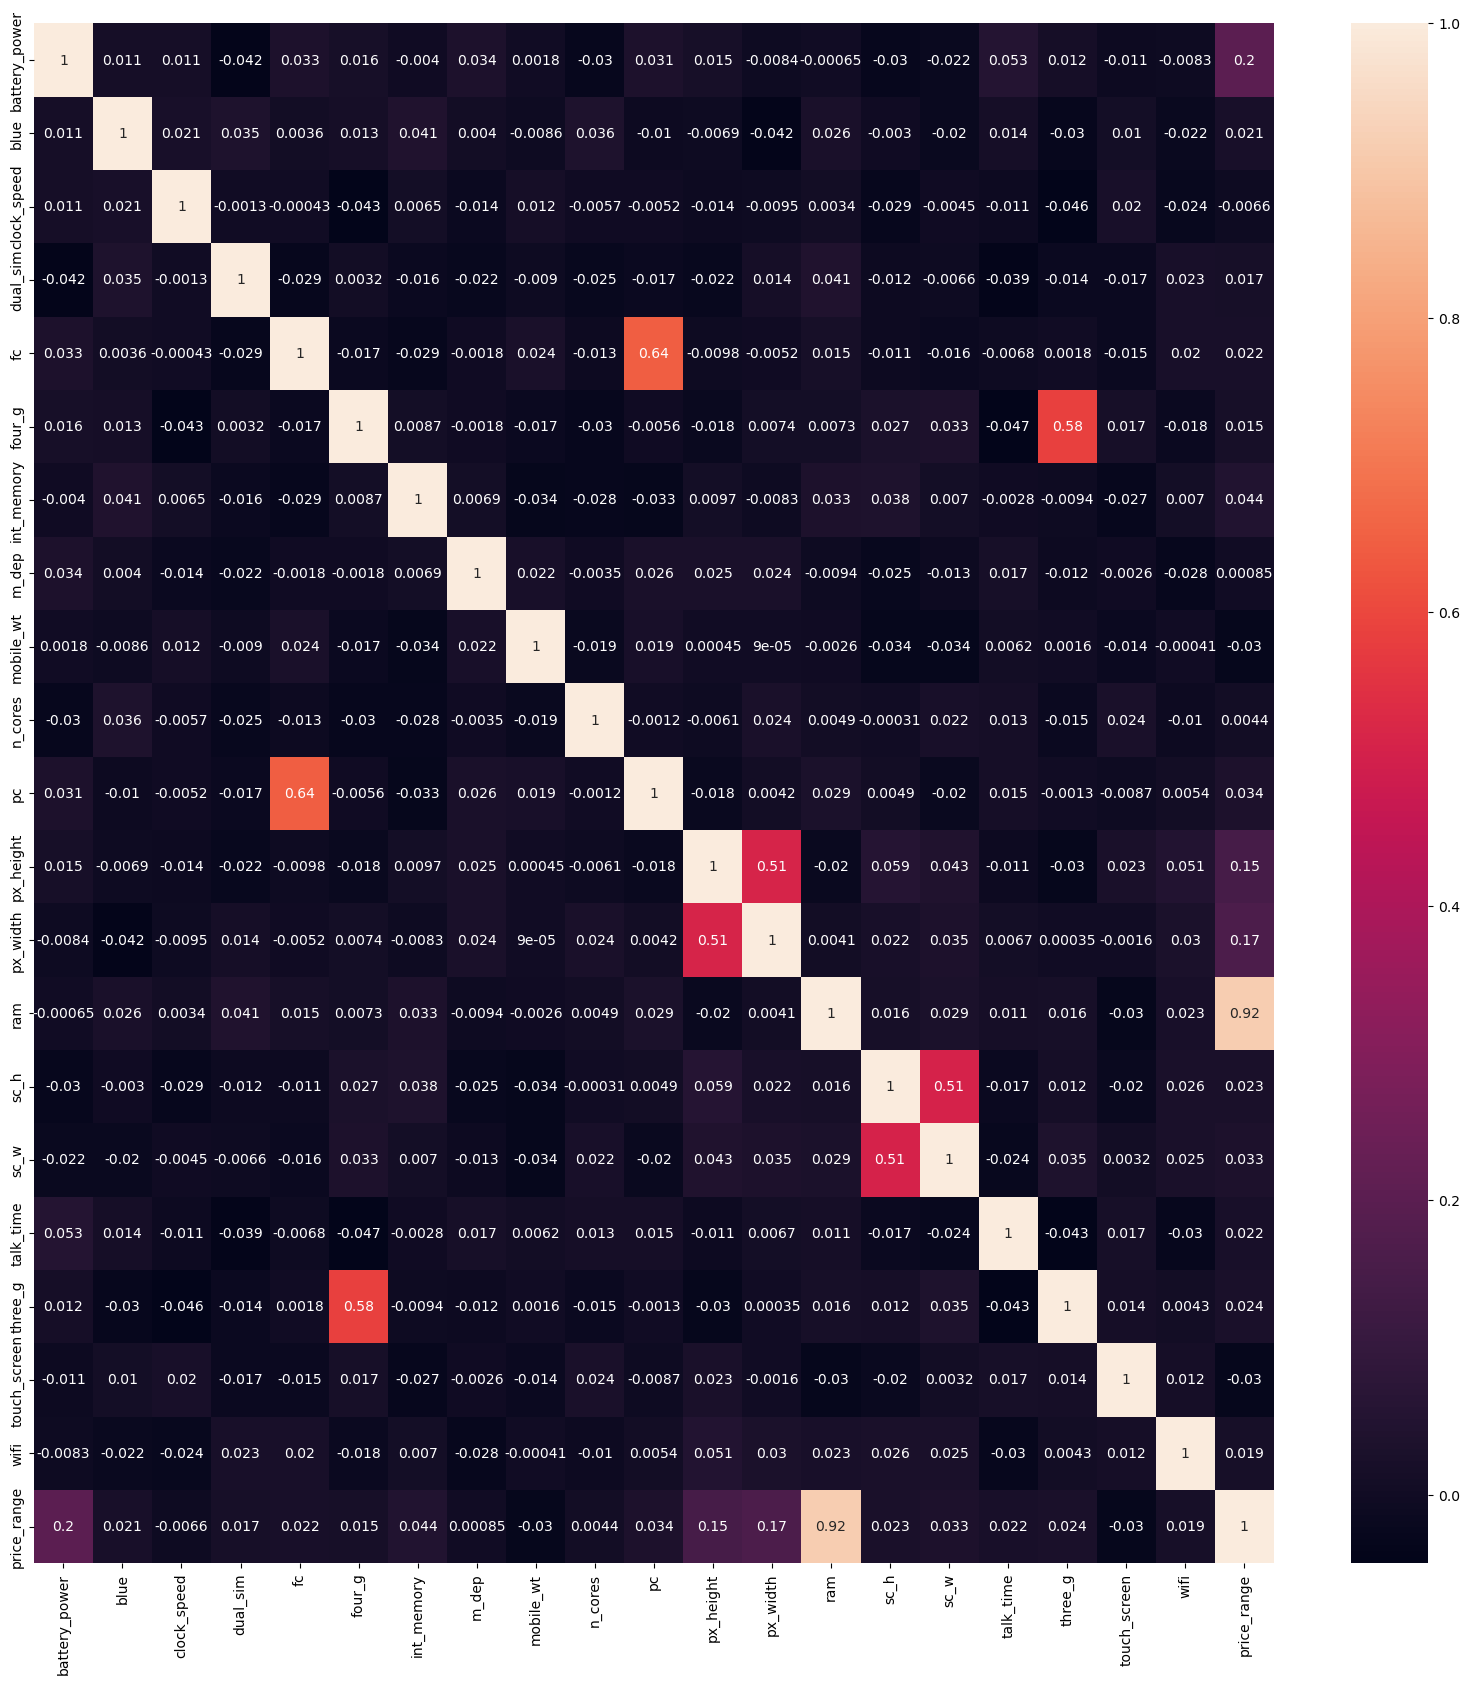

In [18]:
# Checking the corelation for numerical features
plt.figure(figsize=(20,20))
sns.heatmap(data.corr(), annot=True)
plt.show()

## 5)EXPLORATORY DATA ANALYSIS

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

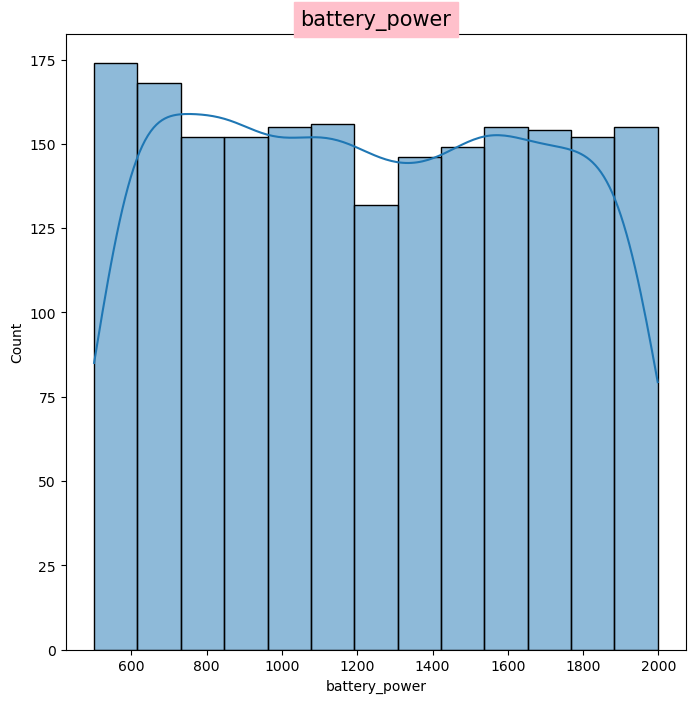

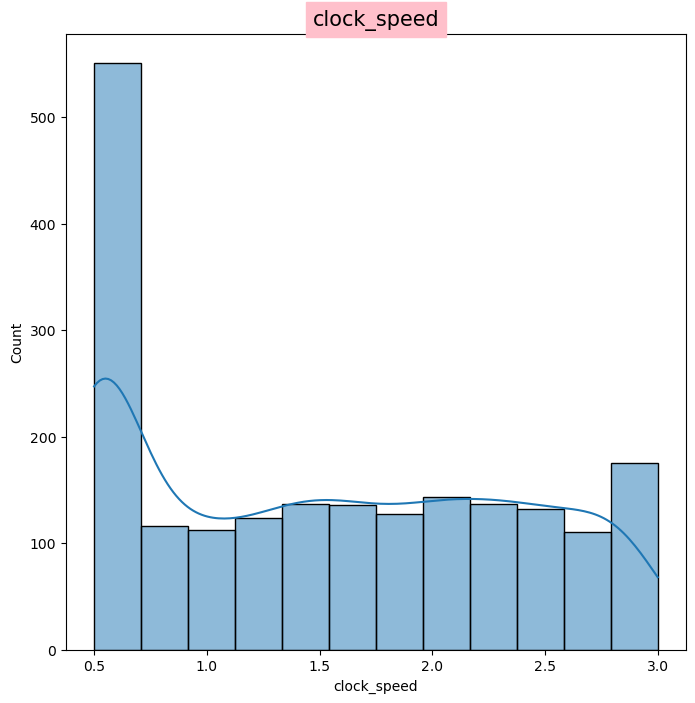

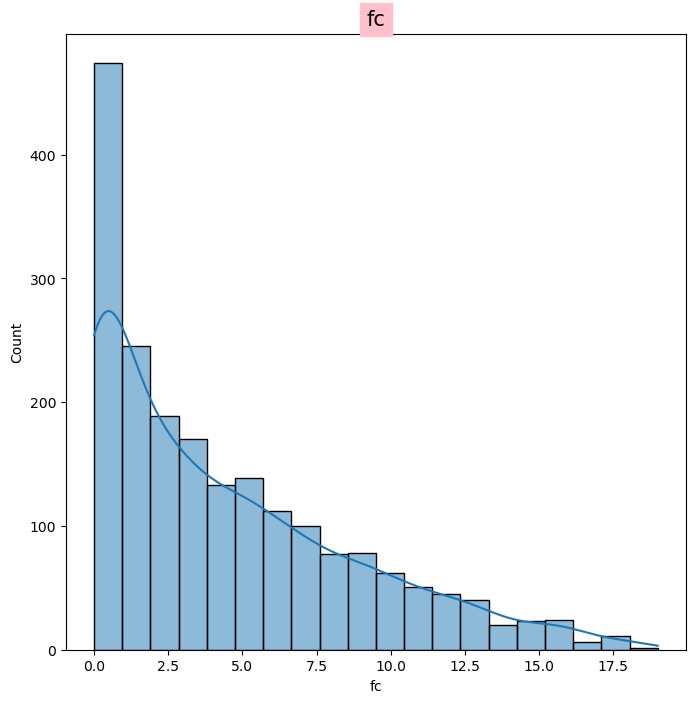

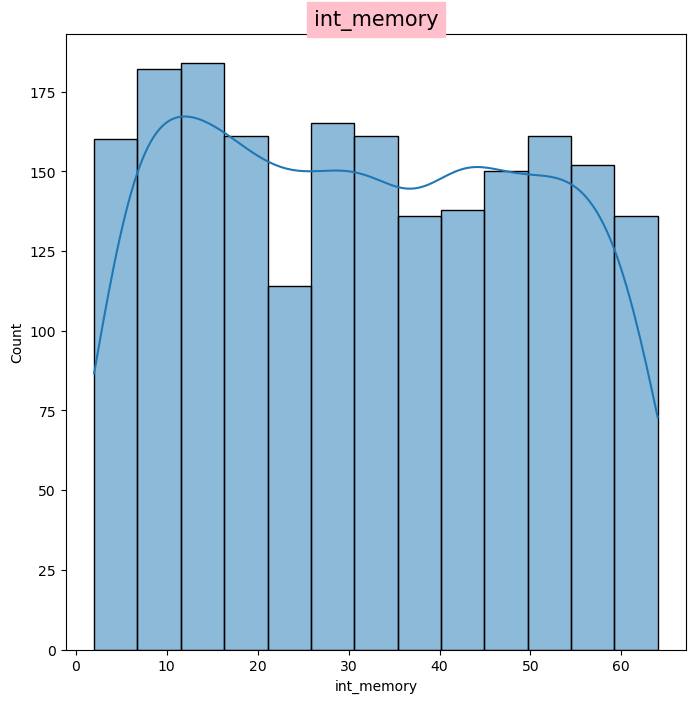

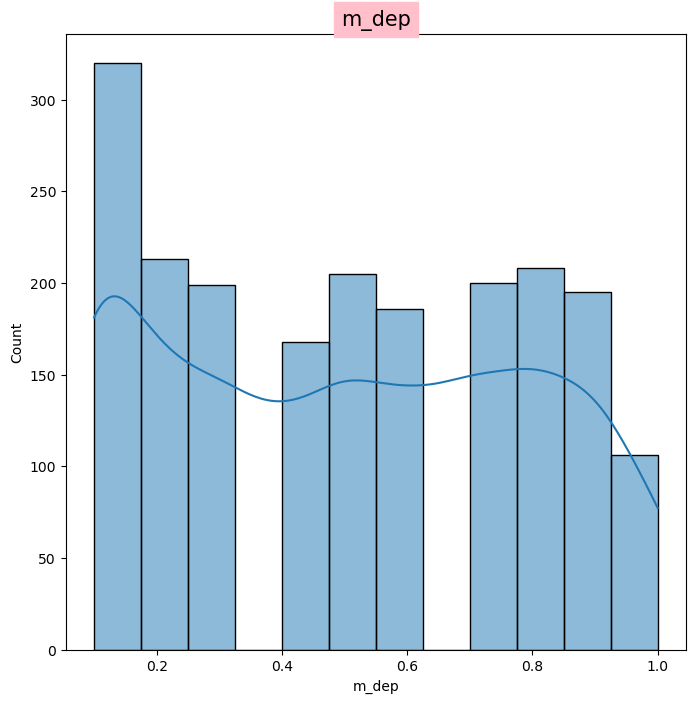

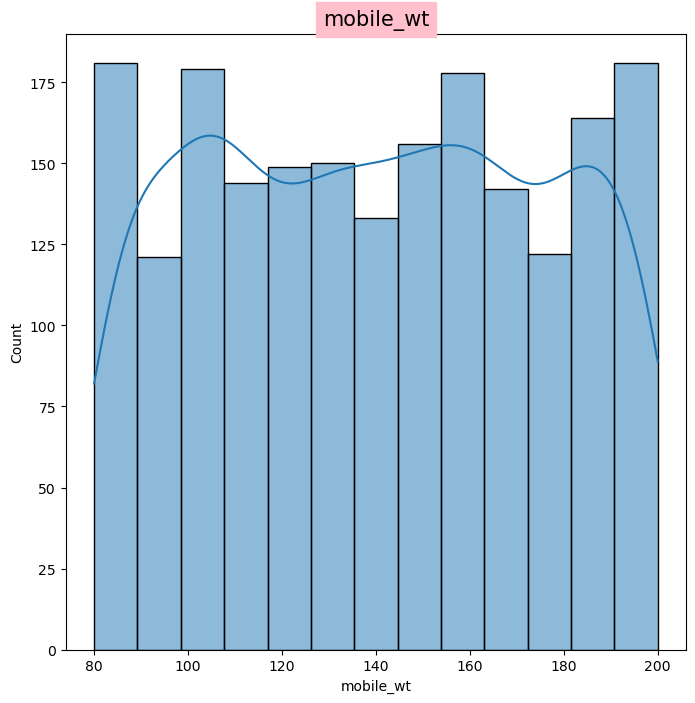

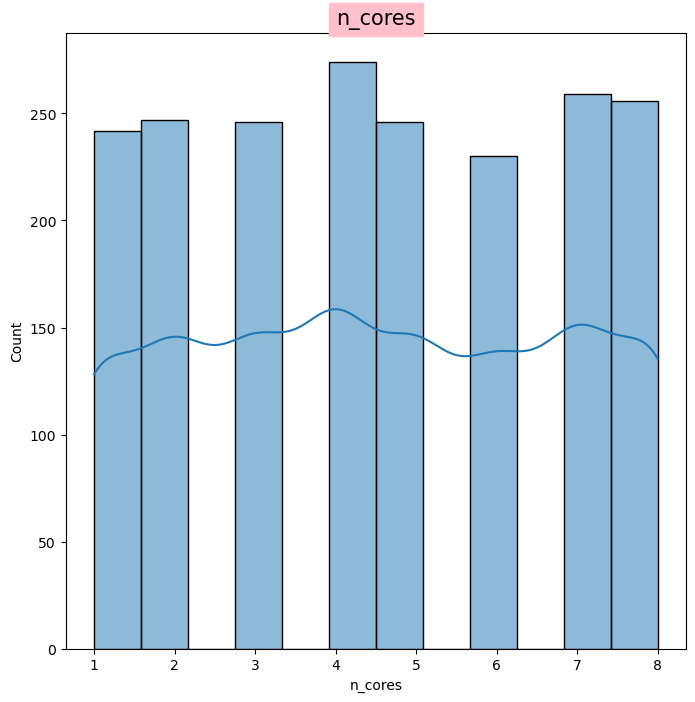

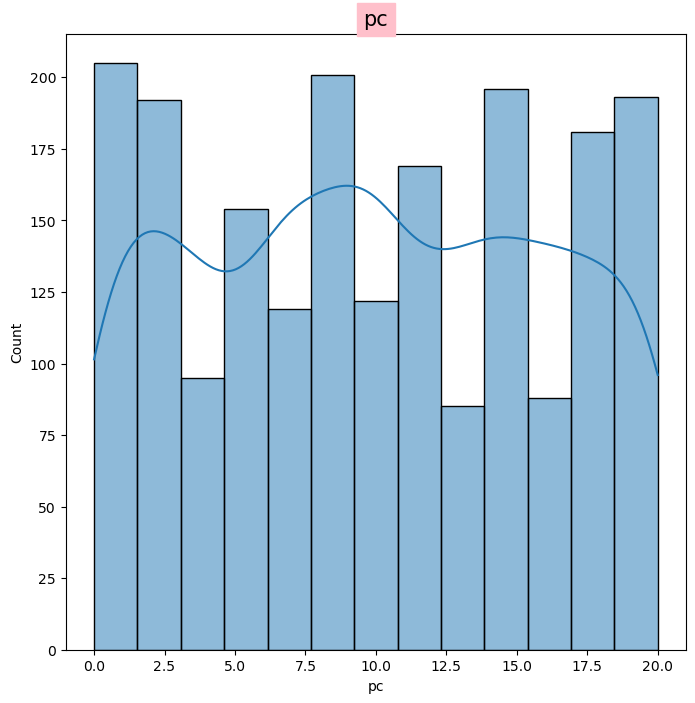

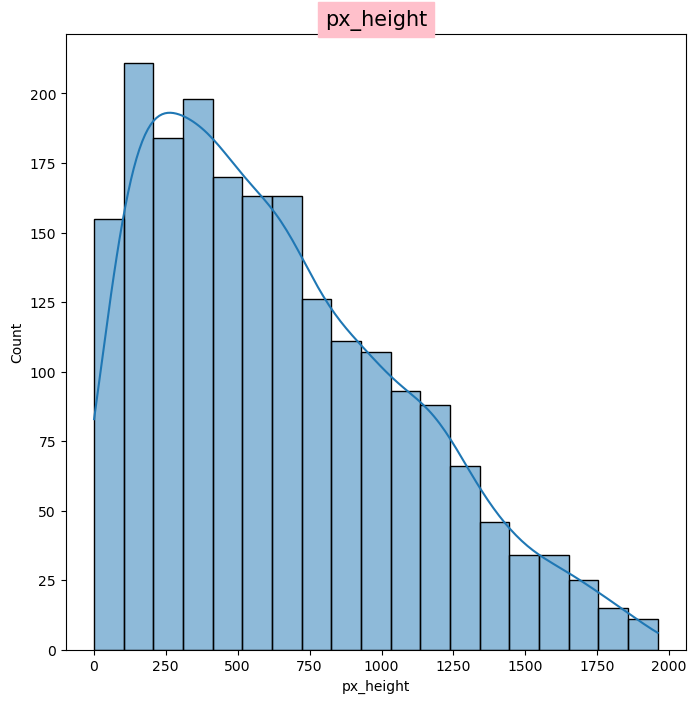

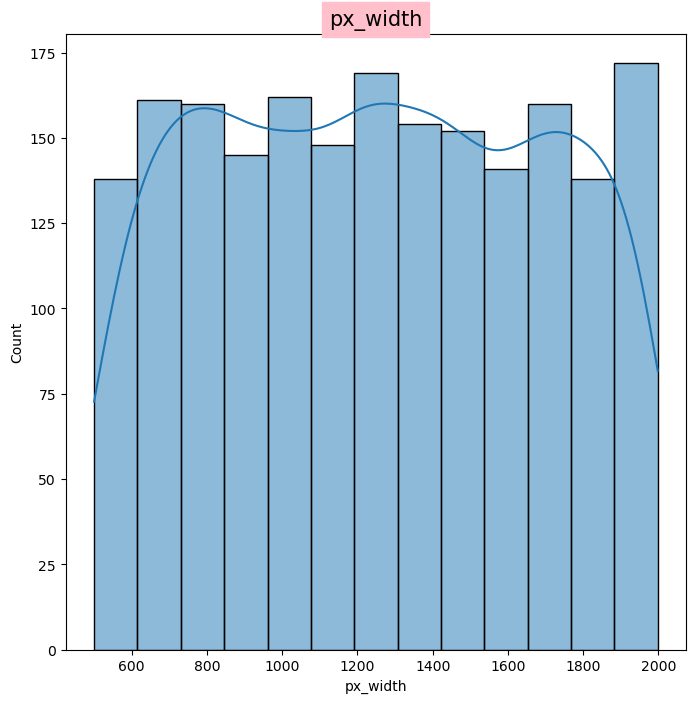

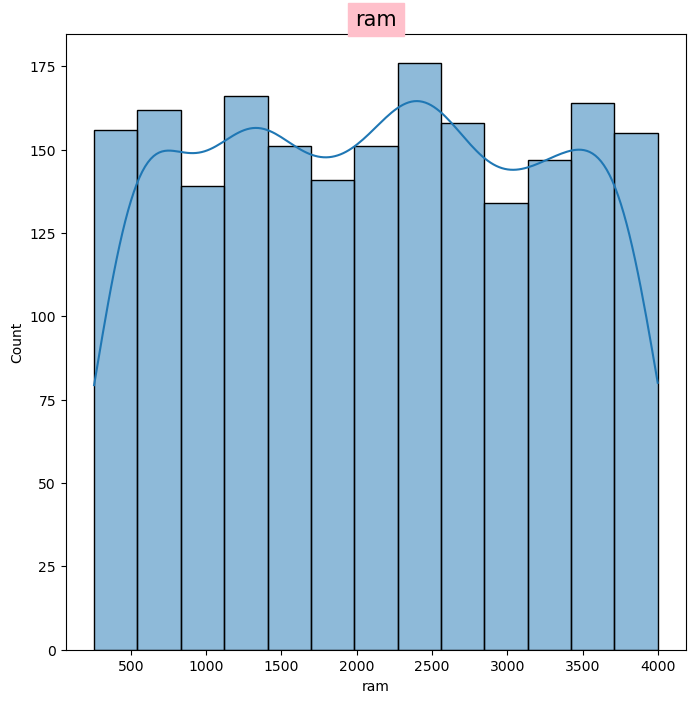

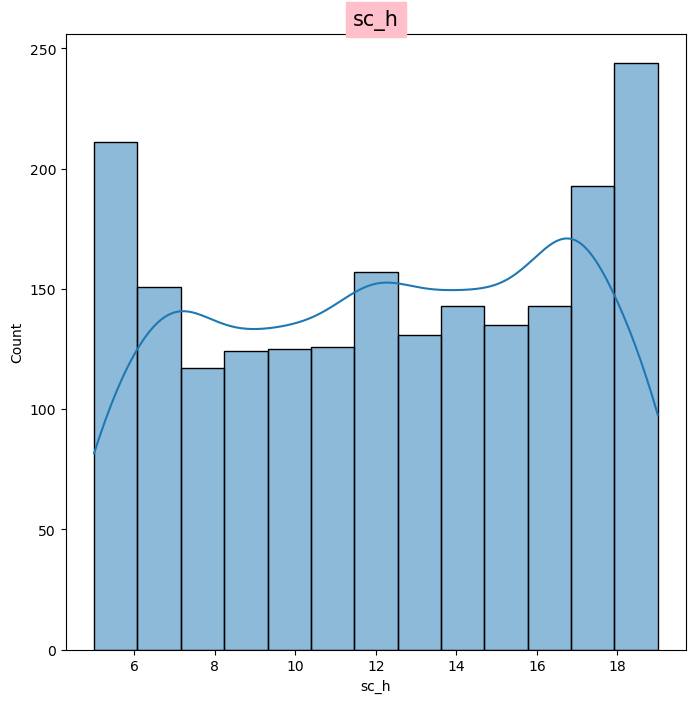

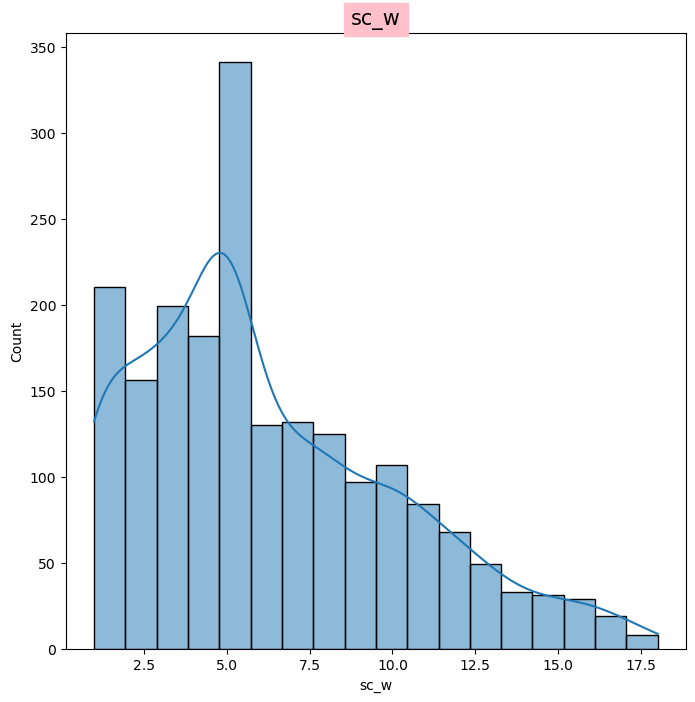

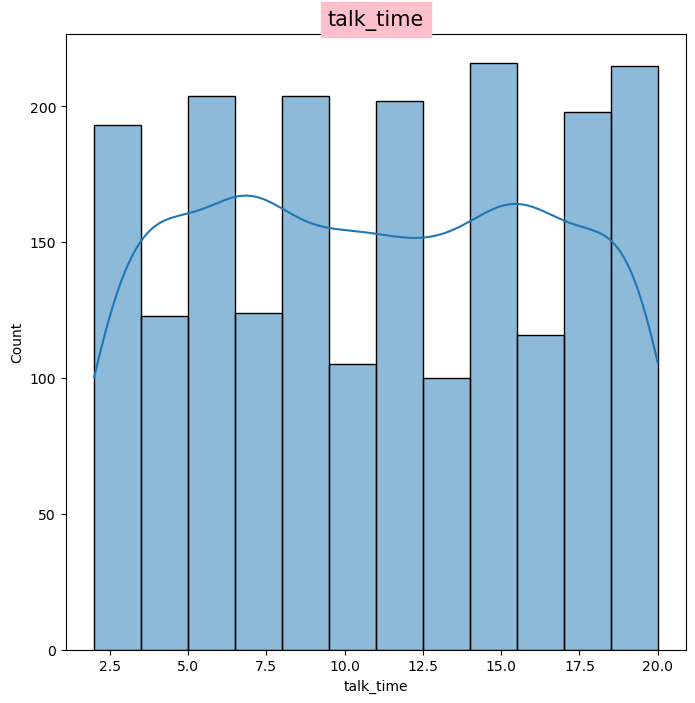

In [20]:
for i in ['battery_power', 'clock_speed', 'fc',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time']:
    plt.figure(figsize=(8,8))
    sns.histplot(data[i],kde=True)
    plt.title(i,backgroundcolor="pink",fontsize=15)
    plt.show()

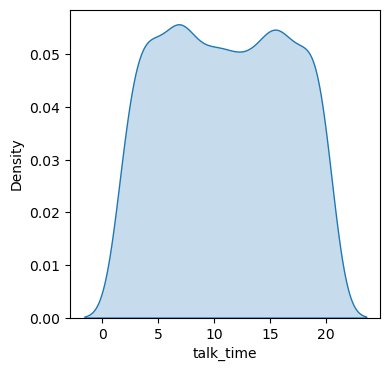

In [21]:
plt.figure(figsize=(4,4))
sns.kdeplot(data[i],fill=True)
plt.show()

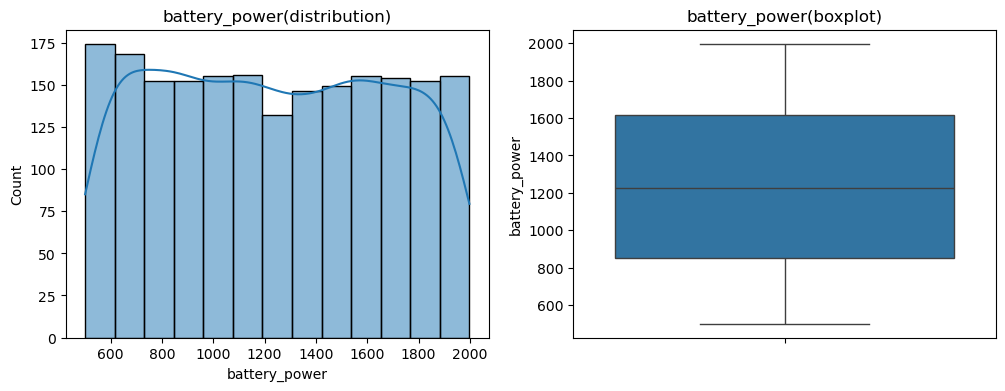

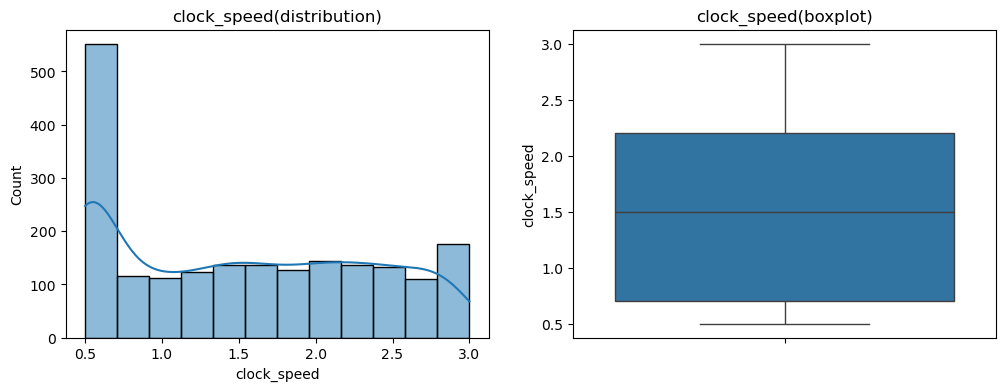

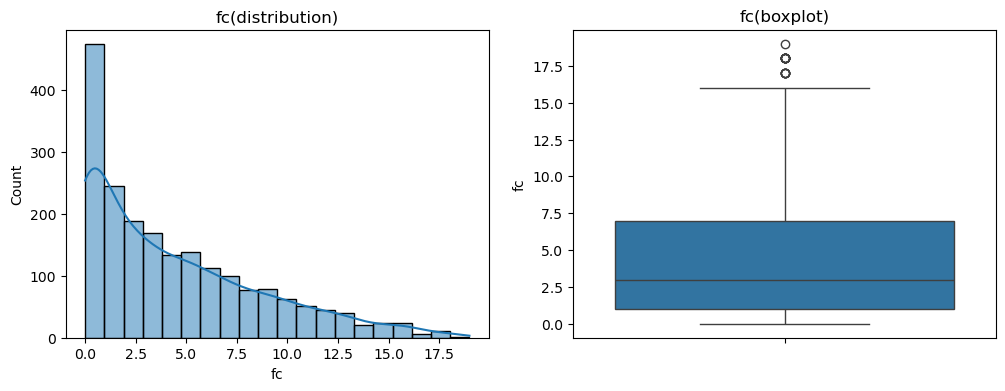

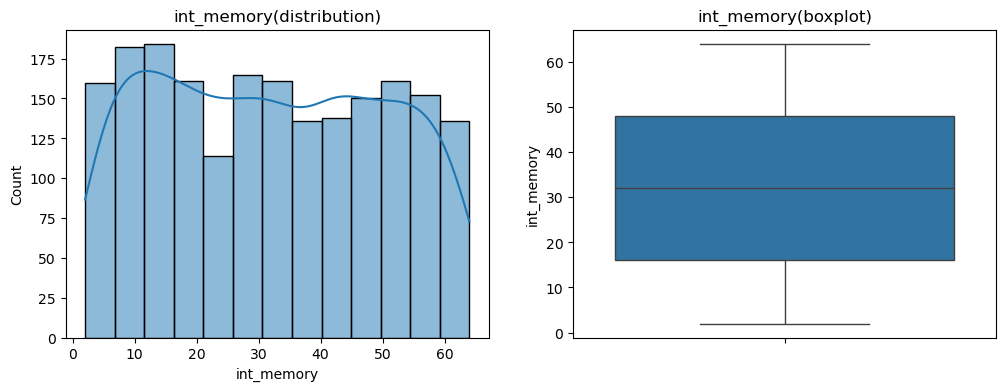

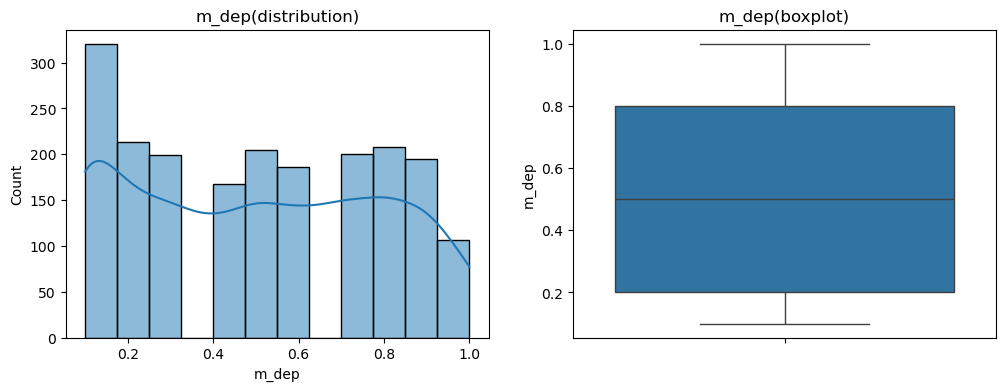

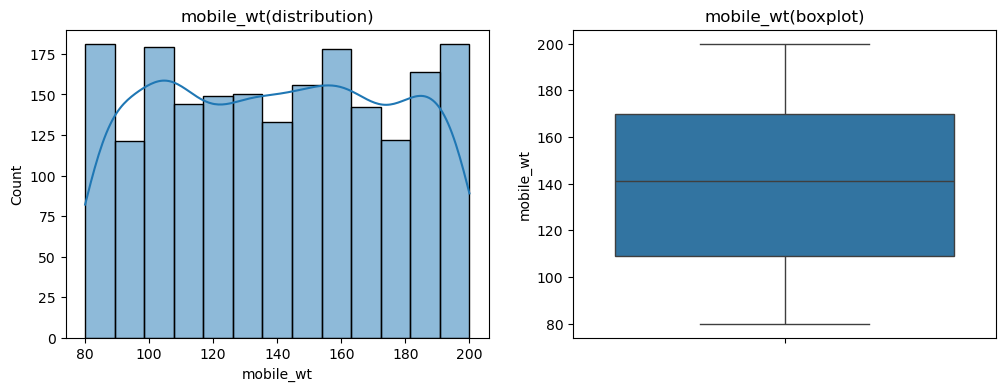

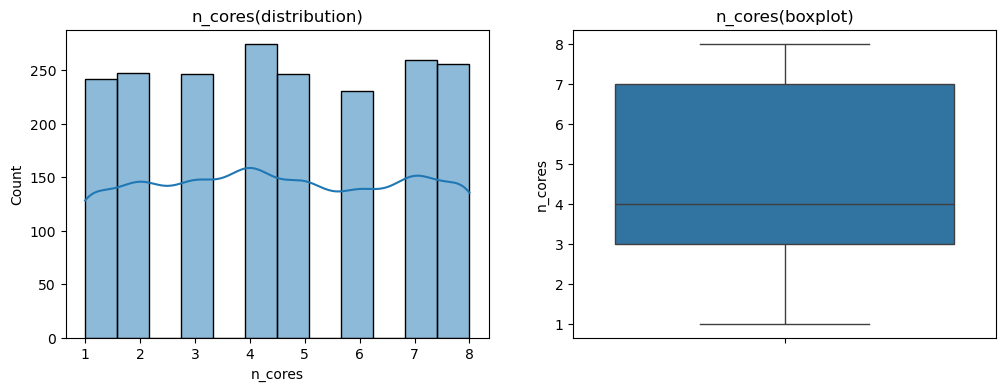

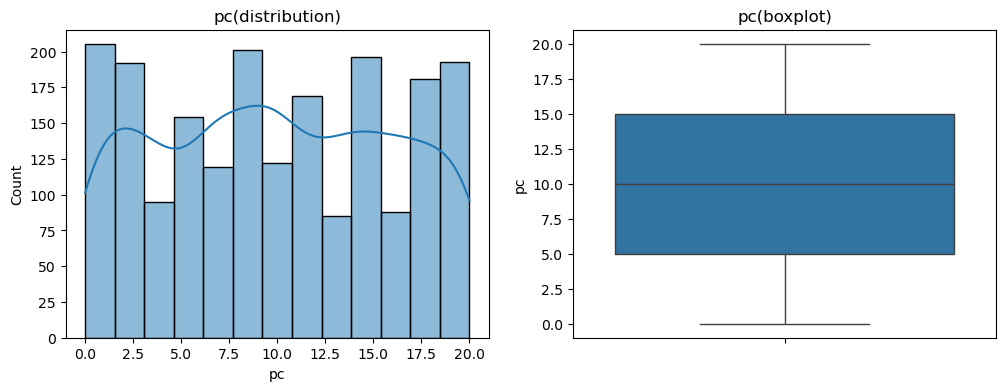

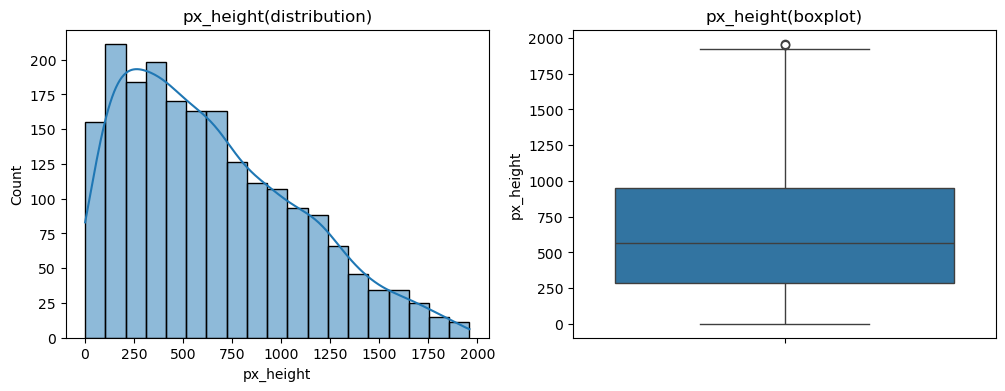

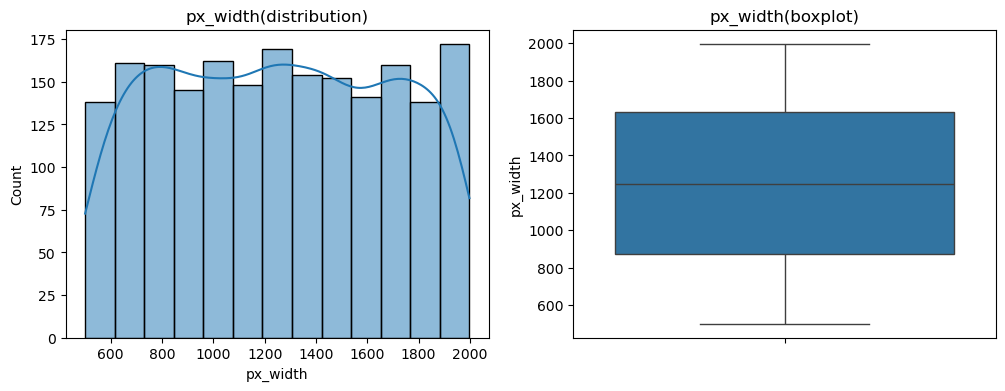

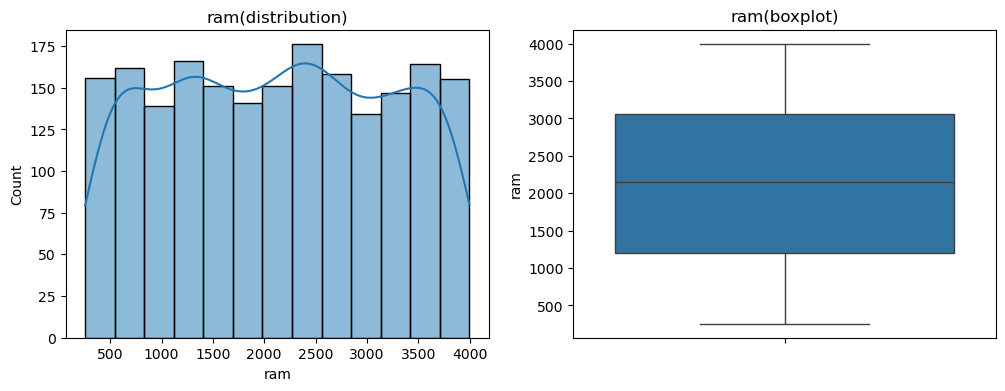

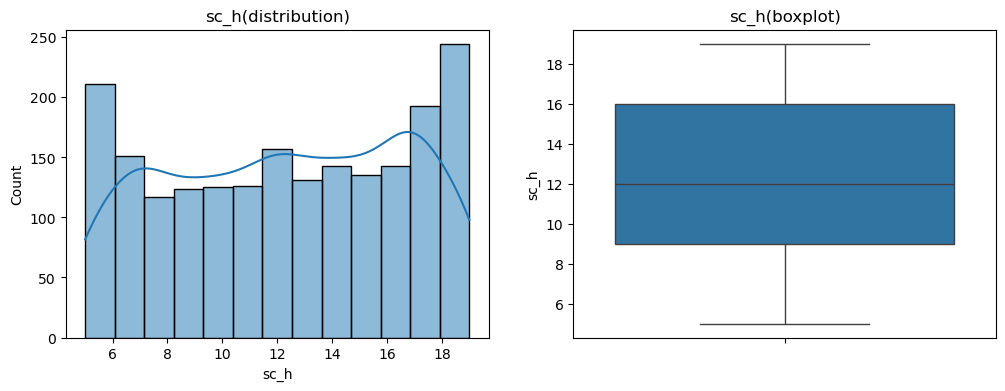

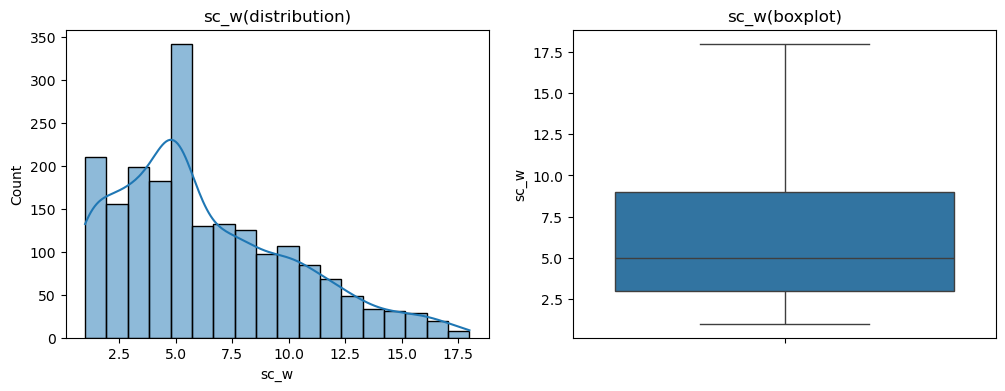

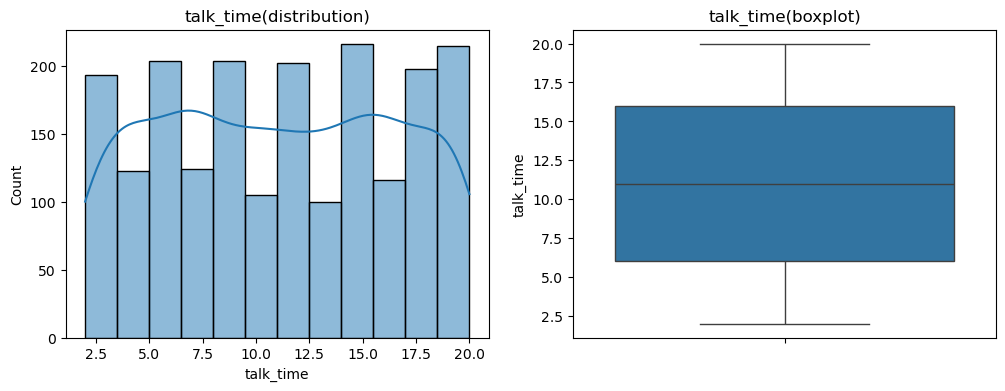

In [22]:
for i in ['battery_power', 'clock_speed', 'fc',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time']:
    plt.figure(figsize=(12,4))
    
    plt.subplot(1,2,1)
    sns.histplot(data[i],kde=True)
    plt.title(f"{i}(distribution)")
    
    
    plt.subplot(1,2,2)
    sns.boxplot(data[i])
    plt.title(f"{i}(boxplot)")
    
    plt.show()

#### After correlation analysis, I analyzed the distribution of continuous features using histograms and KDE plots. This helped me identify skewness and potential outliers. I observed that most features were reasonably distributed, while some like pixel-related features showed slight skewness. I also used boxplots to detect outliers.

#### After analyzing distributions, I used boxplots to study how each numerical feature varies across price categories. I observed that features like RAM show clear separation between classes, while others like battery power show gradual trends. This helped me understand feature importance and relationships with the target variable

#### I first analyzed feature distributions to understand data shape, detect skewness, and identify anomalies. Then I used boxplots against the target variable to evaluate how each feature influences price categories. This helped me identify strong predictors like RAM and understand feature importance before model training.

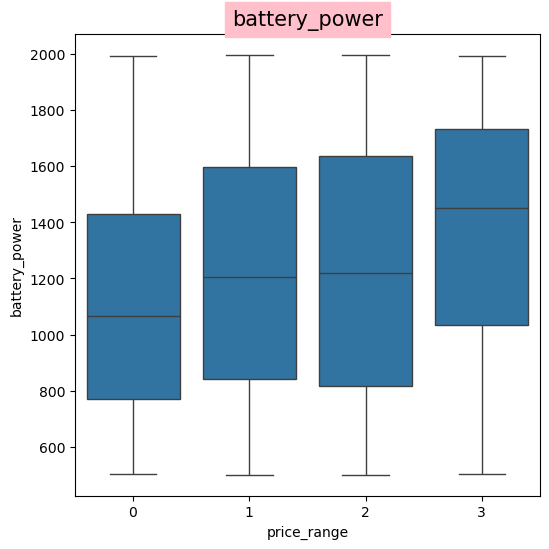

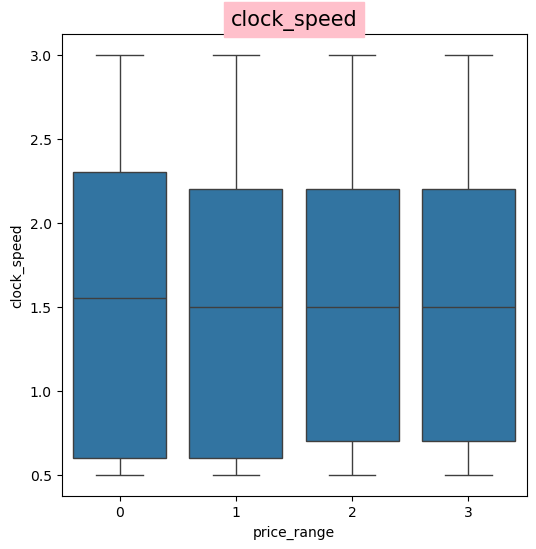

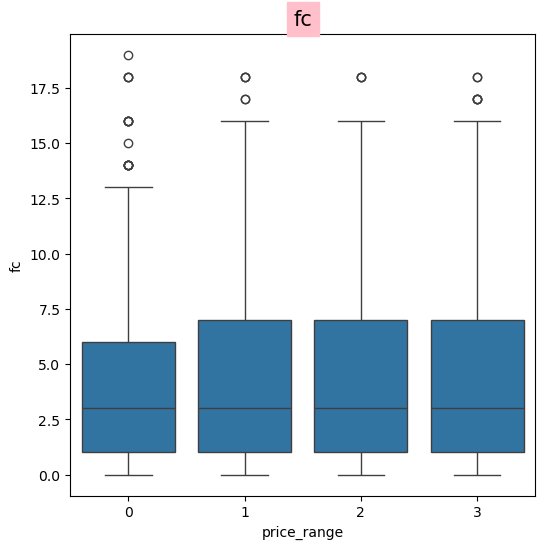

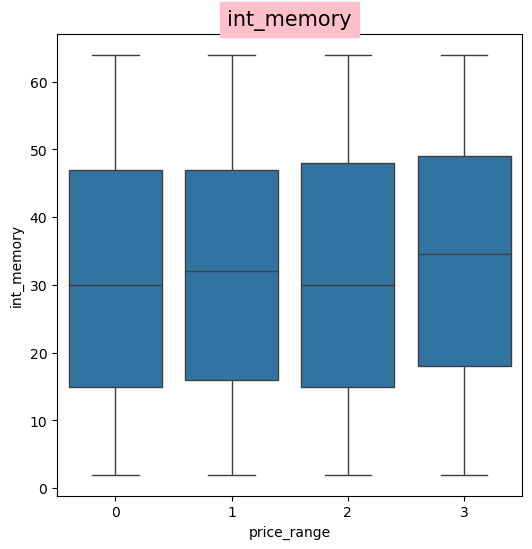

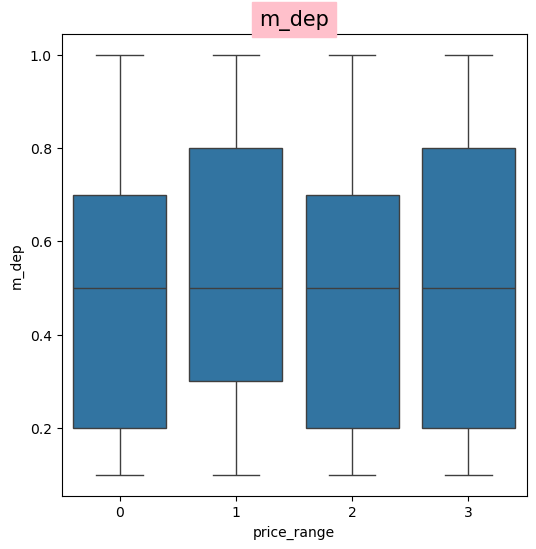

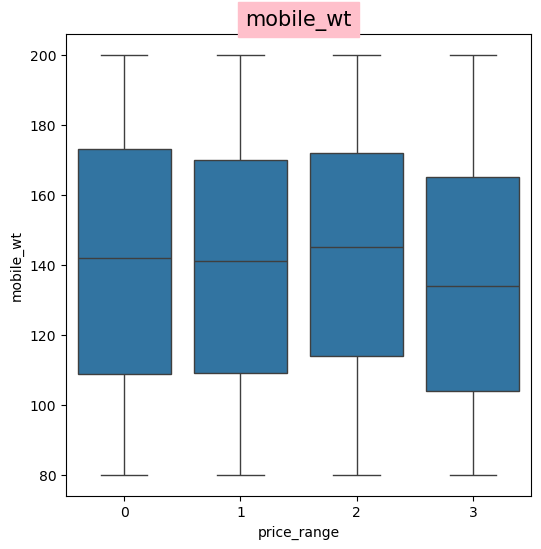

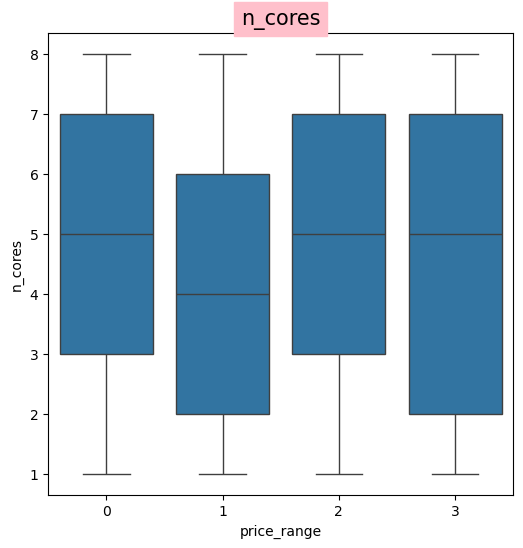

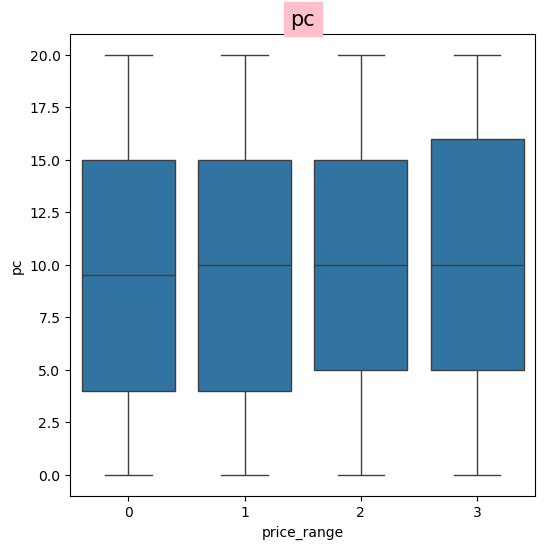

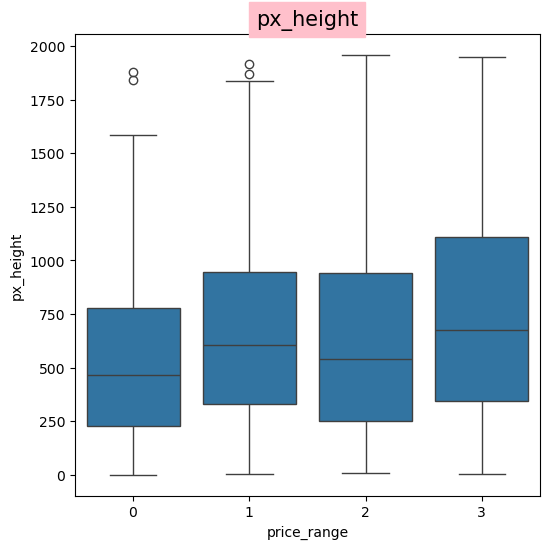

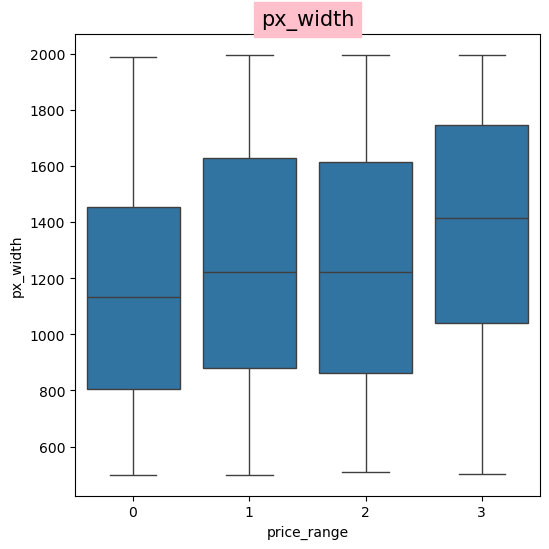

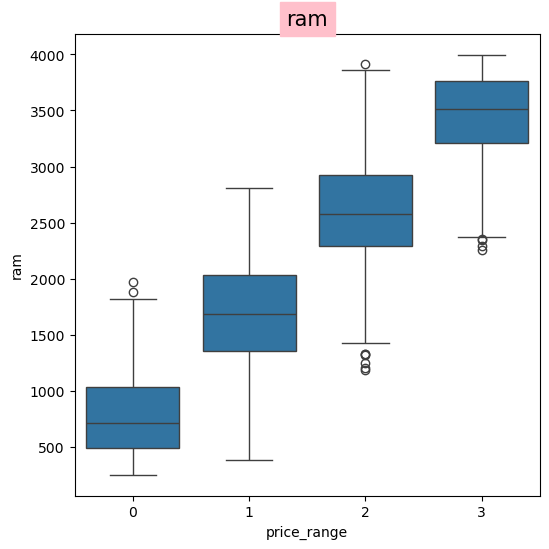

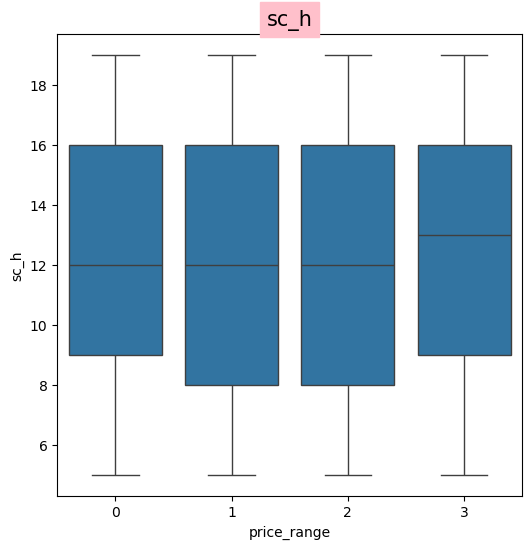

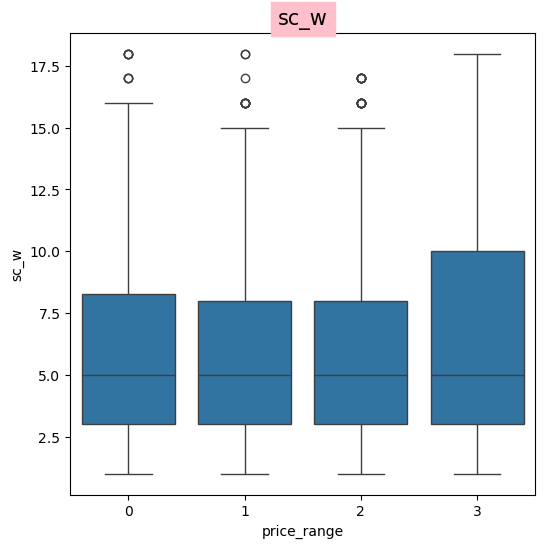

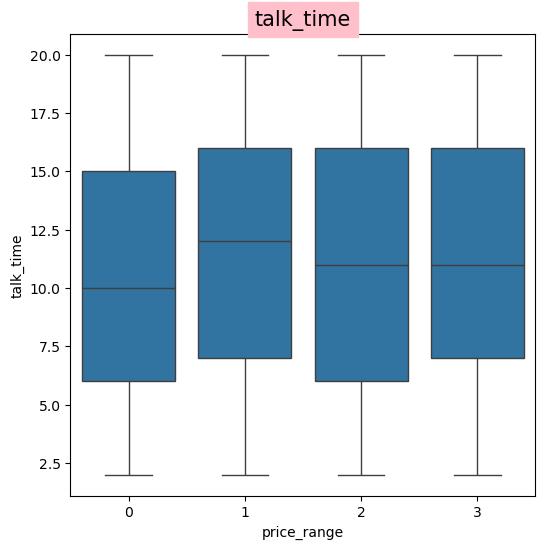

In [23]:
for i in ['battery_power', 'clock_speed', 'fc',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time']:
    plt.figure(figsize=(6,6))
    sns.boxplot(data=data,x ="price_range",y =i)
    plt.title(i,backgroundcolor="pink",fontsize=15)
    plt.show()

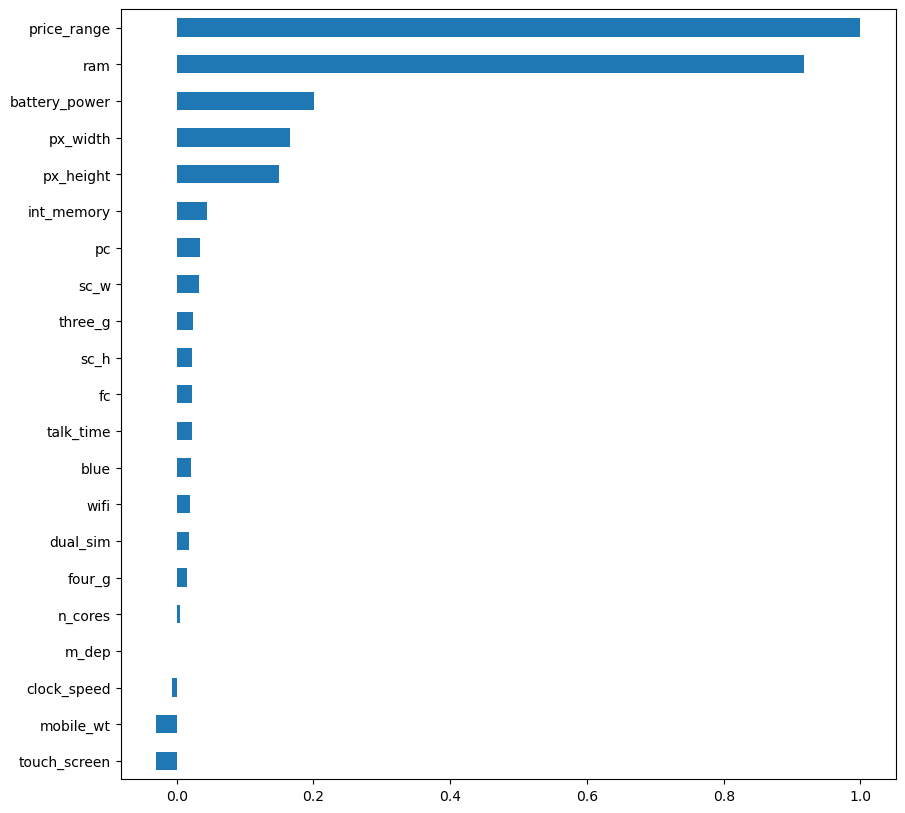

In [24]:
plt.figure(figsize=(10,10))
data.corr()["price_range"].sort_values().plot(kind="barh")
plt.show()

## 6) CREATING MODEL

In [25]:
# Feature and Target
x = data.drop("price_range",axis = 1)
y = data["price_range"]

In [26]:
x_train ,x_test ,y_train , y_test =train_test_split(x,y,test_size=0.2,random_state=42)

### DECISION TREE

In [27]:
from sklearn.tree import DecisionTreeClassifier

In [28]:
dt = DecisionTreeClassifier(criterion ="entropy",max_depth=15,random_state=101)
dt.fit(x_train ,y_train)

# Prediction
y_pred = dt.predict(x_test)


# Accuracy
print("Accuracy:", metrics.accuracy_score(y_test, y_pred)) 

Accuracy: 0.84


In [29]:
print("Accuracy:",dt.score(x_train,y_train))
print("Accuracy:",dt.score(x_test,y_test))

Accuracy: 1.0
Accuracy: 0.84


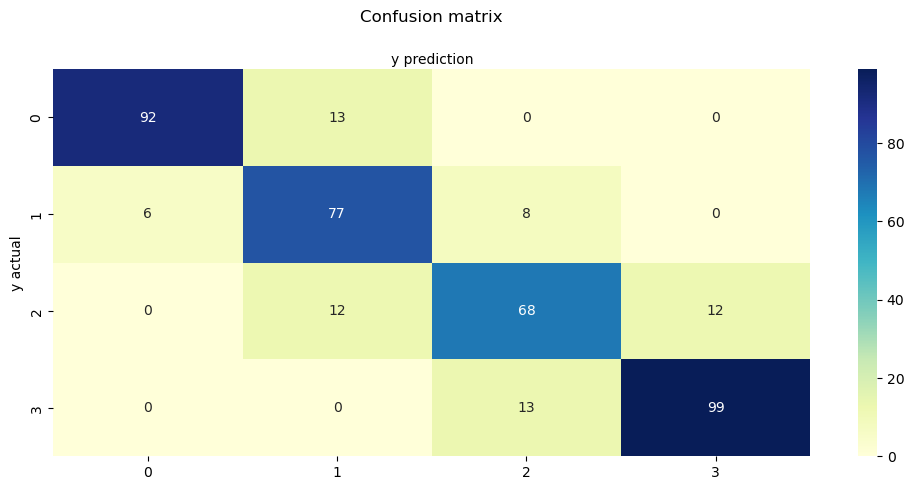

In [30]:
from sklearn.metrics import confusion_matrix
fig, ax = plt.subplots(figsize=(10,5))
cm = metrics.confusion_matrix(y_test,y_pred)
sns.heatmap(metrics.confusion_matrix(y_test,y_pred),annot=True, cmap="YlGnBu" ,fmt='g')
plt.title('Confusion matrix', y=1.1)
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.xlabel('y prediction')
plt.ylabel('y actual')
plt.show()

## RANDOM FOREST

In [31]:
x = data.drop("price_range",axis=1)
y = data["price_range"]

In [32]:
x_train , x_test ,y_train , y_test = train_test_split(x ,y ,test_size=0.2 ,random_state=42)

In [33]:
rf =RandomForestClassifier(random_state=42)


In [34]:
rf.fit(x_train ,y_train)
y_pred = rf.predict(x_test)

print("Random Forest Accurancy:",accuracy_score(y_test,y_pred))

Random Forest Accurancy: 0.8825


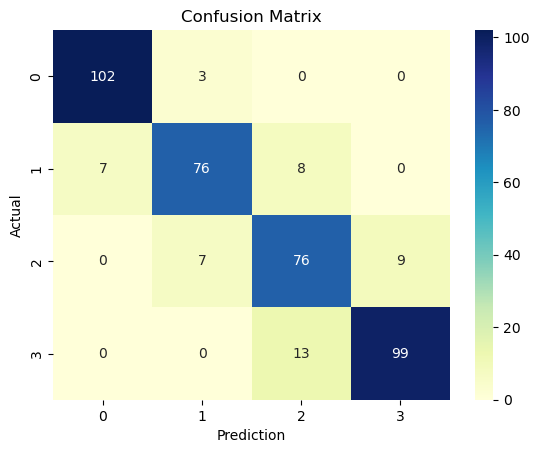

              precision    recall  f1-score   support

           0       0.94      0.97      0.95       105
           1       0.88      0.84      0.86        91
           2       0.78      0.83      0.80        92
           3       0.92      0.88      0.90       112

    accuracy                           0.88       400
   macro avg       0.88      0.88      0.88       400
weighted avg       0.88      0.88      0.88       400



In [35]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, cmap="YlGnBu", fmt='g')

plt.title('Confusion Matrix')
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.show()

print(classification_report(y_test, y_pred))

## SVM

In [36]:
x = data.drop('price_range', axis=1)
y = data['price_range']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

svm = SVC(kernel='linear', C=100, gamma='scale')
svm.fit(x_train_scaled, y_train)
y_preds = svm.predict(x_test_scaled)

print("SVM Accuracy:", accuracy_score(y_test, y_preds))

SVM Accuracy: 0.9725


In [37]:
print("confusion Matrix")
print(confusion_matrix(y_test,y_preds))
print("classification Report")
print(classification_report(y_test,y_preds))

confusion Matrix
[[100   0   0   0]
 [  1  96   3   0]
 [  0   4  95   1]
 [  0   0   2  98]]
classification Report
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       100
           1       0.96      0.96      0.96       100
           2       0.95      0.95      0.95       100
           3       0.99      0.98      0.98       100

    accuracy                           0.97       400
   macro avg       0.97      0.97      0.97       400
weighted avg       0.97      0.97      0.97       400



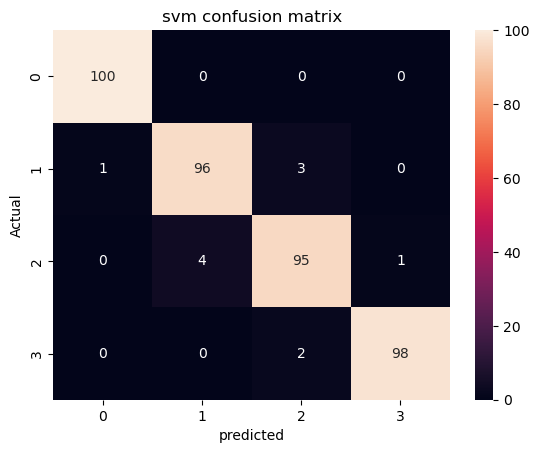

In [38]:
cm = confusion_matrix(y_test,y_preds)
sns.heatmap(cm , annot=True ,fmt="g")
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.title("svm confusion matrix")
plt.show()

# Final Model Selection

# Final Flow

# Model Comparison & Performance Report

 # Models Implemented

#  Model Insights

# Final Model Selection


Support Vector Machine (SVM) is selected as the final model for production.
 Reason:
Highest accuracy (~97%)
Strong generalization (validated via cross-validation)
Effective in handling high-dimensional feature space

# Business Impact

Helps estimate mobile pricing accurately
Supports product design decisions
Enables segmentation:
Low-cost → budget phones
High-cost → premium devices

# Challenges Faced & Solutions


1. Invalid Data Values
Problem:
Features like sc_w and px_height contained zero values, which are unrealistic
Solution:
Replaced with median values
Reason:

Median is robust to outliers and preserves data distribution.

2. Outliers in Data
Problem:
Features like ram, px_height, battery_power showed extreme values
Solution:
Detected using IQR method and boxplots
Not removed aggressively
Reason:

Tree-based models are robust to outliers, and some extreme values represent real-world premium devices.

 3. Overfitting in Decision Tree
Problem:
High training accuracy but lower test accuracy
Solution:
Controlled using max_depth parameter
Reason:

Limiting tree depth improves generalization.

 4. Feature Scaling Requirement
Problem:
SVM performance was poor without scaling
Solution:
Applied StandardScaler
Reason:

SVM is distance-based and sensitive to feature magnitude.

 5. Model Selection
Problem:
Multiple models with different strengths
Solution:
Compared using accuracy + cross-validation
Reason:

Ensures model generalizes well, not just fits test data.


# Final Conclusion

### This project successfully predicts cell price ranges using machine learning models. Among all models, SVM achieved the highest performance (~97%) and demonstrated strong generalization. Random Forest provided valuable feature importance insights, highlighting RAM as the most critical factor. The final model can help businesses optimize pricing strategies and design competitive products.